In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### 1. refractive index of Polystyrene - 소스코드와 일치

Sample을 두개의 물질 (PS and Air/Vacuum)으로 구성할 때에는 Bruggeman approximation과 계산 결과가 거의 유사한 Maxwell-Garnett equation을 사용하는데,
MG를 이용한 결과는 소스코드의 결과와 완전히 일치한다. (`_get_n_eff_ps_matrix_mg`로 구현됨)

Bruggeman approximation 또한 본인 모델에 `_get_n_eff_ps_matrix`로 구현되어 있으며, 기본적으로 이 모델을 사용한다.

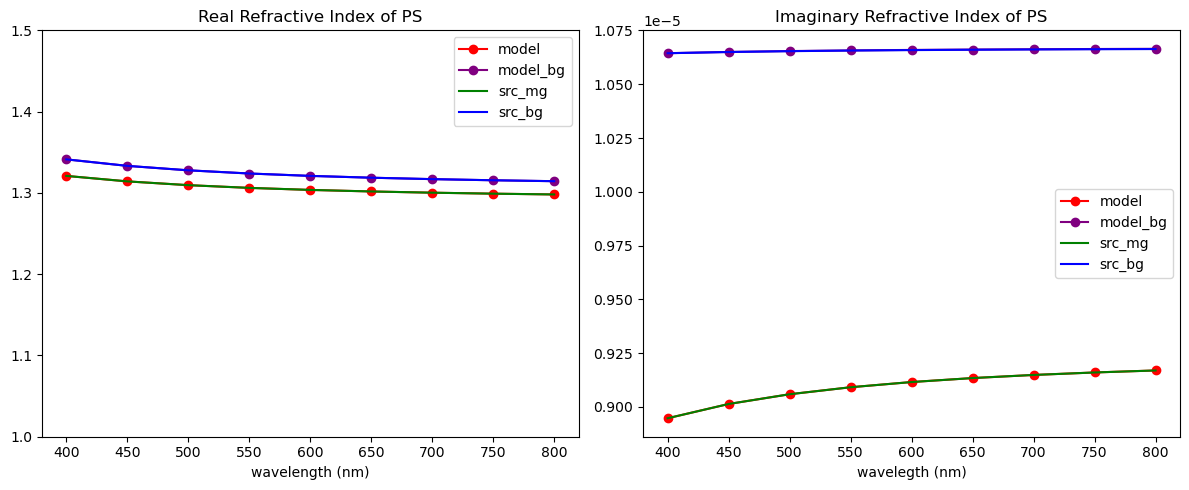

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

model_data = pd.read_csv("diagnostic_table.csv")
model_wvls = model_data["wavelength_nm"]
model_neff_mg_real = model_data["n_eff_mg_real"]
model_neff_mg_imag = model_data["n_eff_mg_imag"]
model_neff_bg_real = model_data["n_eff_bg_real"]
model_neff_bg_imag = model_data["n_eff_bg_imag"]

src_neff_data = pd.read_csv("data/src_neff.csv")
src_wvls = src_neff_data["wvls"]
src_neff_mg_real = src_neff_data["neff_mg_real"]
src_neff_mg_imag = src_neff_data["neff_mg_imag"]
src_neff_bg_real = src_neff_data["neff_bg_real"]
src_neff_bg_imag = src_neff_data["neff_bg_imag"]


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(model_wvls, model_neff_mg_real, color='red', label="model", marker= "o")
axes[0].plot(model_wvls, model_neff_bg_real, color='purple', label="model_bg", marker= "o")
axes[0].plot(src_wvls, src_neff_mg_real, color='green', label="src_mg")
axes[0].plot(src_wvls, src_neff_bg_real, color='blue', label="src_bg")
axes[0].set_title('Real Refractive Index of PS')
axes[0].set_xlabel('wavelength (nm)')
axes[0].legend()
axes[0].set_ylim([1, 1.5])

axes[1].plot(model_wvls, model_neff_mg_imag, color='red', label="model", marker= "o")
axes[1].plot(model_wvls, model_neff_bg_imag, color='purple', label="model_bg", marker= "o")
axes[1].plot(src_wvls, src_neff_mg_imag, color='green', label="src_mg")
axes[1].plot(src_wvls, src_neff_bg_imag, color='blue', label="src_bg")
axes[1].set_title('Imaginary Refractive Index of PS')
axes[1].set_xlabel('wavelegth (nm)')
axes[1].legend()
axes[0].set_ylim([1., 1.5])

plt.tight_layout()
plt.show()


#### 2. Structure Factor 비교 - 소스코드와 일치

monodisperse한 필름에 대해서 Percus-Yevick equation을 통해 Structure Factor를 계산한다.

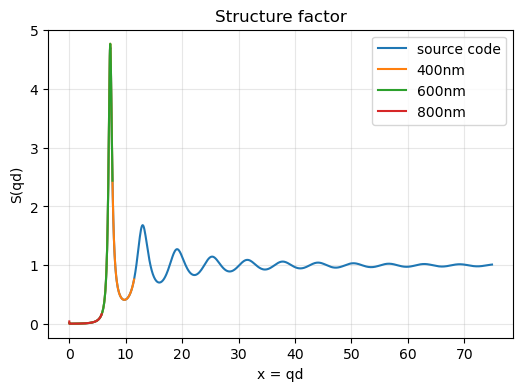

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

d = 0.138 * 2

model_data = pd.read_csv("data/model_structure.csv")
model_q400 = model_data['q400']
model_S_q400 = model_data['S_q400']
model_q500 = model_data['q500']
model_S_q500 = model_data['S_q500']
model_q600 = model_data['q600']
model_S_q600 = model_data['S_q600']
model_q700 = model_data['q700']
model_S_q700 = model_data['S_q700']
model_q800 = model_data['q800']
model_S_q800 = model_data['S_q800']

src_struc_data = pd.read_csv("data/src_structure.csv")
src_qd = src_struc_data["qd"]
src_S_qd = src_struc_data["s_data"]

plt.figure(figsize=(6, 4))
plt.plot(src_qd, src_S_qd, label="source code")
plt.plot(model_q400*d, model_S_q400, label="400nm")   
plt.plot(model_q600*d, model_S_q600, label="600nm")  
plt.plot(model_q800*d, model_S_q800, label="800nm")  
plt.xlabel("x = qd")
plt.ylabel("S(qd)")
plt.title("Structure factor")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### 3. Scattering / Absorbing Coefficient / Asymmetry parameter / transport length - 소스코드와 일치 

Scattering coefficient($\mu_s$)는 $l_s$의 역수로 number density와 $C^{sample}_{sca}$의 곱이다

number density가 이상이 없으므로 $C^{sample}_{sca}$ value 또한 소스코드와 일치한다.

$C_{sca}^{sample} = 2π∫\frac{dC_{sca}^{Mie}}{dΩ}S(q)sinθdθ$이므로, 본인의 모델의 `_get_mie_absorbing` 함수가 소스코드와 동일한 결과를 반환함을 알 수 있다.

Assymetry parameter 또한 일치한다는 것은 소스코드와 모델의 transport length 차이가 없음을 의미하며 Asymmetry parameter 계산 과정에 존재하는 theta pdf도 동일하다는 것을 의미한다.

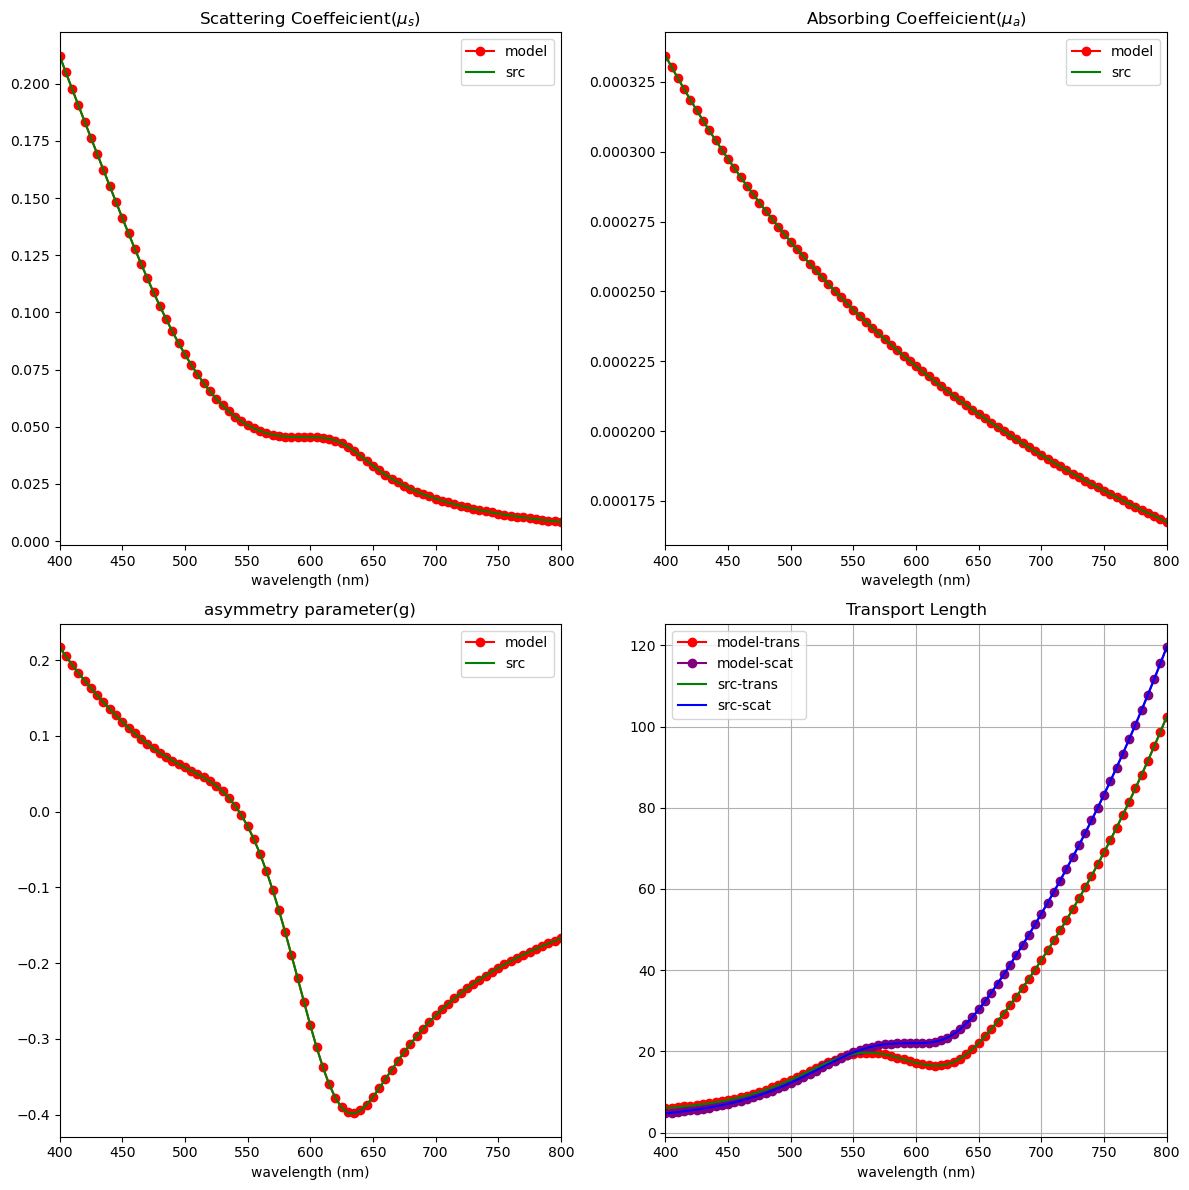

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model_data = pd.read_csv("diagnostic_table.csv")
model_wvls = model_data["wavelength_nm"]
model_l_scat = model_data["l_scat_sample_um"]
model_mu_scat = 1 / model_l_scat
model_mu_abs = model_data["mu_a_bg"]
model_l_star = model_data["l_transport_um"]
model_g = model_data["g"]

model_csca_data = np.load("data/model_phase.npz")
model_csca_wvls = model_csca_data["wvls"]
model_csca = model_csca_data["csca"]

src_mu_data = np.load("data/src_mu.npz")
src_wvls = src_mu_data["wvls"]
src_mu_scat = src_mu_data["mu_scat"]
src_mu_abs = src_mu_data["mu_abs"]
src_csca_sample = src_mu_data["csca_sample"]

src_transport_data = pd.read_csv("data/src_transport_length.csv")
src_transport_wvls = src_transport_data["wvls"]
src_l_star = src_transport_data["l_star"]
src_g = src_transport_data["g"]


fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0,0].plot(model_wvls, model_mu_scat, color='red', label="model", marker= "o")
axes[0,0].plot(src_wvls, src_mu_scat, color='green', label="src")
axes[0,0].set_title(r'Scattering Coeffeicient($\mu_{s}$)')
axes[0,0].set_xlabel('wavelength (nm)')
axes[0,0].legend()
axes[0,0].set_xlim(400, 800)


axes[0,1].plot(model_wvls, model_mu_abs, color='red', label="model", marker= "o")
axes[0,1].plot(src_wvls, src_mu_abs, color='green', label="src")
axes[0,1].set_title(r'Absorbing Coeffeicient($\mu_{a}$)')
axes[0,1].set_xlabel('wavelegth (nm)')
axes[0,1].legend()
axes[0,1].set_xlim(400, 800)

axes[1,0].plot(model_wvls, model_g, color='red', label="model", marker= "o")
axes[1,0].plot(src_transport_wvls, src_g, color='green', label="src")
axes[1,0].set_title('asymmetry parameter(g)')
axes[1,0].set_xlabel('wavelength (nm)')
axes[1,0].legend()
axes[1,0].set_xlim(400, 800)

axes[1,1].plot(model_wvls, model_l_star, color='red', label="model-trans", marker= "o")
axes[1,1].plot(model_wvls, model_l_scat, color='purple', label="model-scat", marker= "o")
axes[1,1].plot(src_transport_wvls, src_l_star/1000, color='green', label="src-trans")
axes[1,1].plot(src_transport_wvls, 1/src_mu_scat, color='blue', label="src-scat")
axes[1,1].set_title('Transport Length')
axes[1,1].set_xlabel('wavelength (nm)')
axes[1,1].legend()
axes[1,1].set_xlim(400, 800)
axes[1,1].grid()

plt.tight_layout()
plt.show()